# Segmentasi Wilayah Multi-Polutan (NO₂, SO₂, CO) — PCA + k-Means + Silhouette
**Eksperimen reduksi dimensi, analisis Silhouette, dan pemetaan segmentasi wilayah menggunakan KNIME**

Dokumen ini menyajikan analisis pengelompokan spasial (*spatial clustering*) terhadap 37 titik pengamatan. Setiap titik diwakili oleh **204 fitur TSFEL** (68 fitur × 3 polutan: NO₂, SO₂, CO) yang diekstraksi dengan dua pendekatan, yaitu **interpolasi Linier** dan **interpolasi Polinomial**.

Seluruh pengolahan utama saya kerjakan di **KNIME Analytics Platform**. Notebook ini menjelaskan apa yang saya lakukan di KNIME dan mereplikasi hasilnya di Python agar bisa ditampilkan di web statis.

**Tahapan yang saya kerjakan:**
1. Mengambil tabel fitur Linier dan Polinomial dari basis data MySQL (37 daerah × 204 fitur).
2. Menormalisasi seluruh fitur dengan **Z-score**.
3. Mereduksi dimensi dengan **PCA** ke dalam tiga skenario: **37, 74, dan 204 dimensi**.
4. Menjalankan **k-Means** untuk **k = 2, 3, 4, 5, dan 6** pada setiap skenario.
5. Menghitung **Silhouette Coefficient** untuk menentukan **k terbaik** pada tiap jalur dan tiap reduksi.
6. Menggabungkan hasil klaster dengan koordinat daerah lalu memetakannya.

## 1. Arsitektur workflow eksperimen pada KNIME

Saya membuat **dua workflow** dengan struktur yang sama persis: `kl.knwf` untuk fitur **Linier** dan `Poly-PSD.knwf` untuk fitur **Polinomial**. Perbedaannya hanya pada tabel sumber di MySQL.


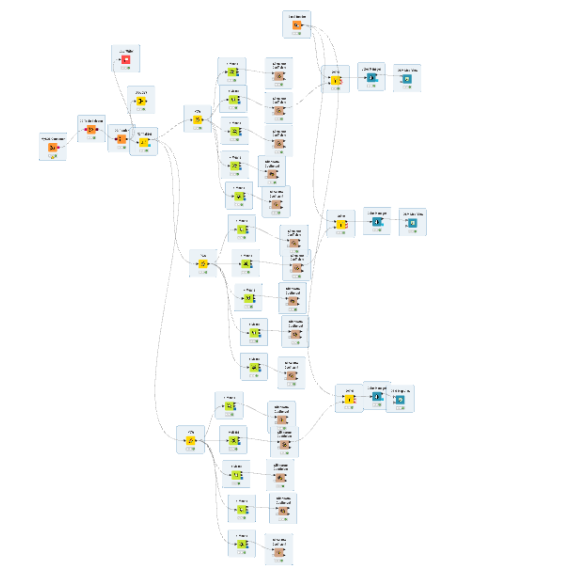







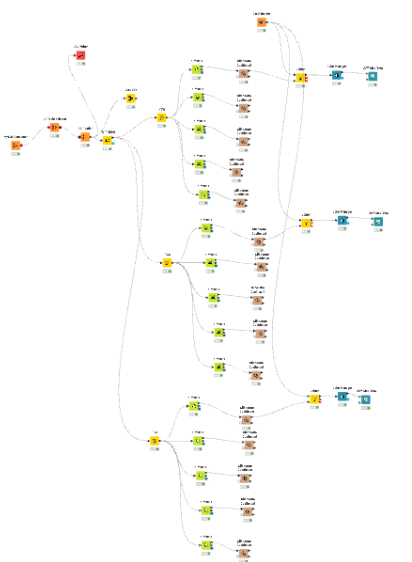


### Penjelasan alur node (pipeline)

**1. MySQL Connector → DB Table Selector → DB Reader**
Saya menghubungkan KNIME ke server MySQL, memilih tabel hasil ekstraksi (`ekstraksi_fitur_linear` untuk jalur Linier dan `ekstraksi_fitur_polynomial` untuk jalur Polinomial), lalu memuatnya ke memori KNIME. Hasilnya tabel **37 baris × 207 kolom**: tiga kolom identitas (`id`, `nama`, `daerah`) dan **204 kolom fitur**.

**2. GroupBy (kelompok = `daerah`)**
Node ini saya pakai untuk melihat daerah unik. Hasilnya tidak saya sambungkan ke node lain, jadi tidak memengaruhi perhitungan klaster.

**3. Normalizer (Z-score)**
Saya menormalisasi ke-204 fitur dengan Z-score (kolom `id` dikecualikan). Langkah ini perlu karena skala fitur TSFEL sangat berbeda (misalnya energi sinyal bernilai sangat besar dibanding rasio atau kemiringan), sehingga tanpa normalisasi fitur bernilai besar akan mendominasi jarak Euclidean.


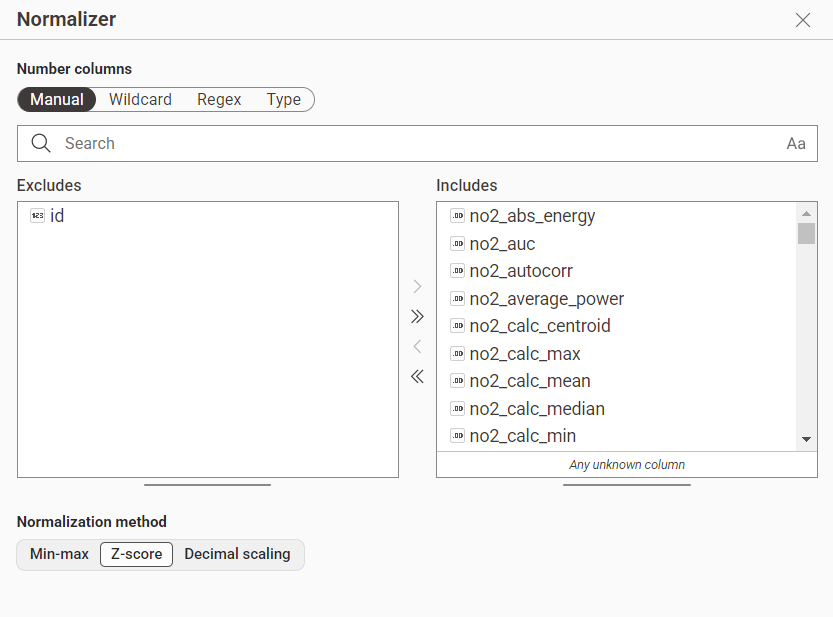



**4. PCA — tiga cabang reduksi dimensi**
Dari data yang sudah dinormalisasi, saya membuat tiga node PCA dengan jumlah dimensi tetap:

| Cabang | Reduksi | Keterangan |
|---|---|---|
| PCA #1 | 204 → **37** dimensi | sama dengan jumlah baris data |
| PCA #2 | 204 → **74** dimensi | dua kali jumlah baris |
| PCA #3 | 204 → **204** dimensi | tanpa pengurangan jumlah kolom |


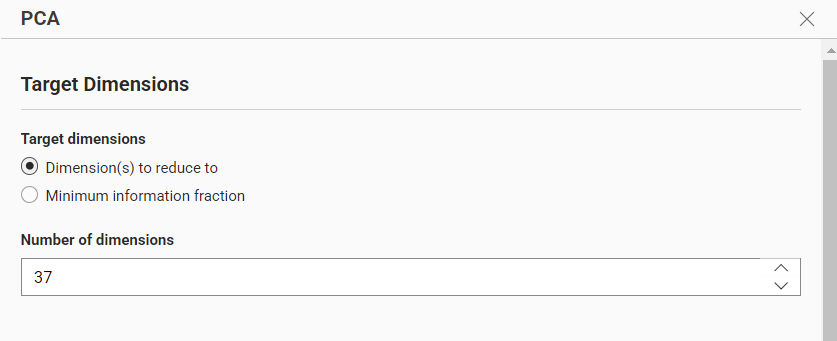



**5. k-Means (k = 2 sampai 6) pada setiap cabang PCA**
Pada tiap cabang PCA saya memasang **lima node k-Means** dengan k = 2, 3, 4, 5, dan 6, sehingga ada 15 node k-Means per jalur. Pengaturannya: inisialisasi *random*, *static seed* = 0, maksimum 99 iterasi, kolom `id` dikecualikan.

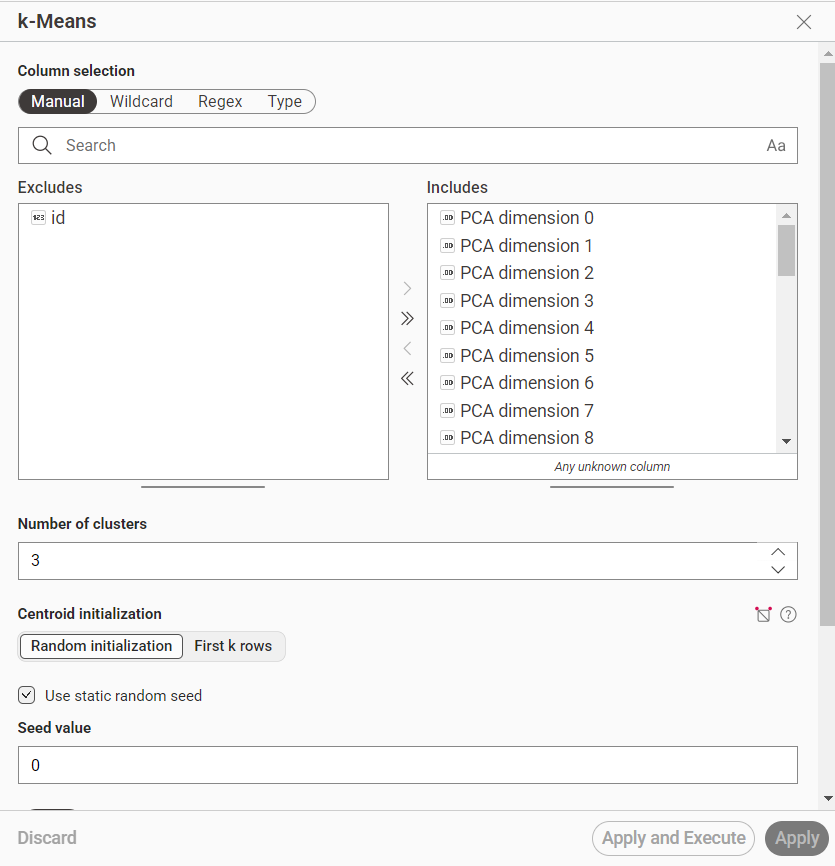


**6. Silhouette Coefficient**
Setiap node k-Means saya sambungkan ke node Silhouette Coefficient (kolom klaster = `Cluster`, jarak Euclidean). Node ini mengeluarkan *Overall Mean Silhouette*, yang saya bandingkan antar-k untuk menentukan **k terbaik**:

$$S(i)=\frac{b(i)-a(i)}{\max\{a(i),\,b(i)\}}$$

dengan $a(i)$ rata-rata jarak titik $i$ ke titik lain dalam klaster yang sama (kohesi), dan $b(i)$ rata-rata jarak titik $i$ ke klaster tetangga terdekat (separasi).


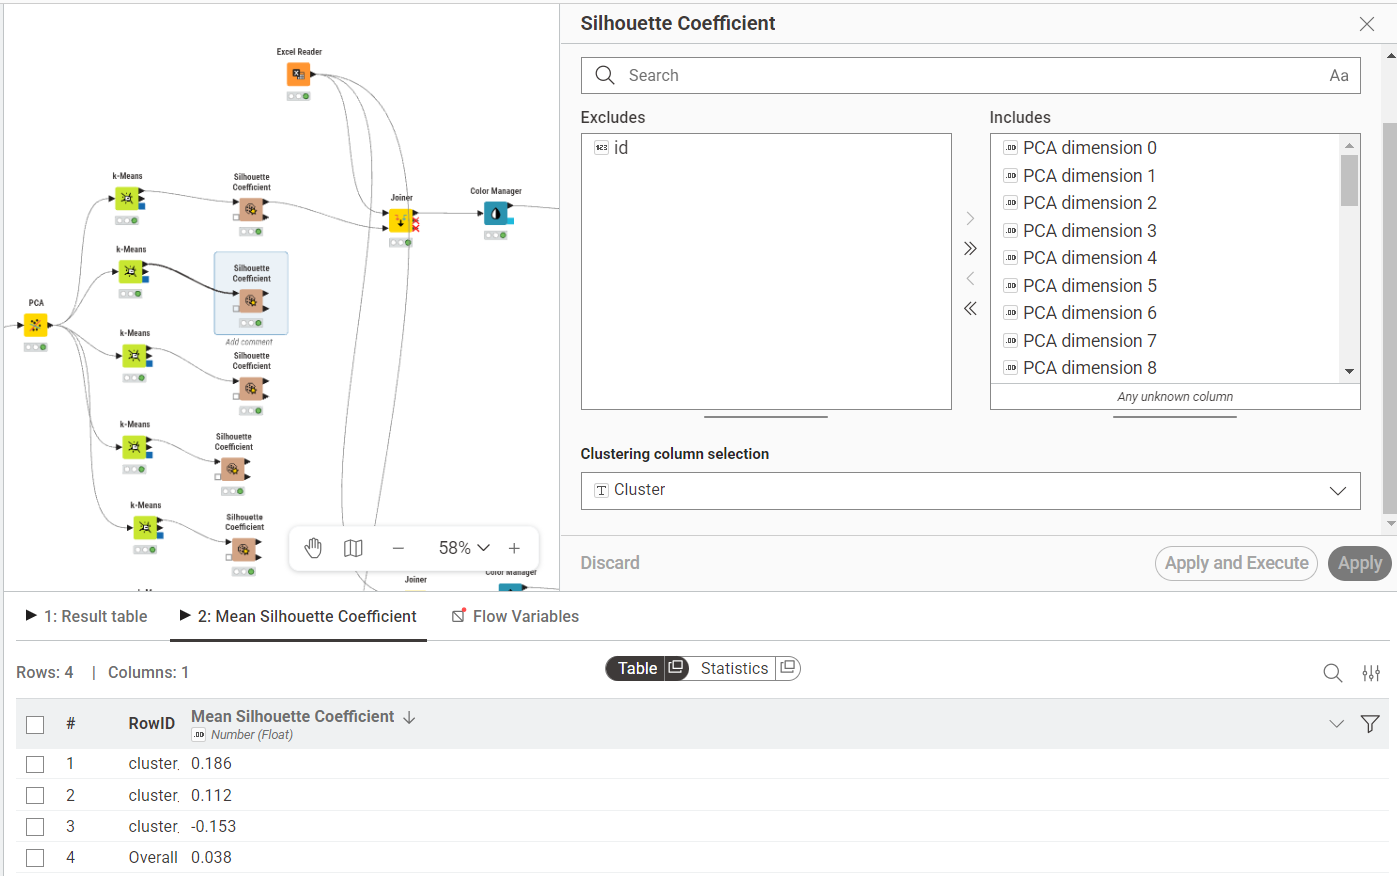


**7. Excel Reader → Joiner → Color Manager → OSM Map View**
Untuk k terbaik, saya membaca koordinat dari `Long_Daerah.xlsx` (kolom `daerah`, `latitude`, `longitude`), menggabungkannya dengan hasil klaster lewat **Joiner** pada kolom `daerah`, memberi warna per klaster dengan **Color Manager** (palet Set1), lalu menampilkannya di **OSM Map View**.

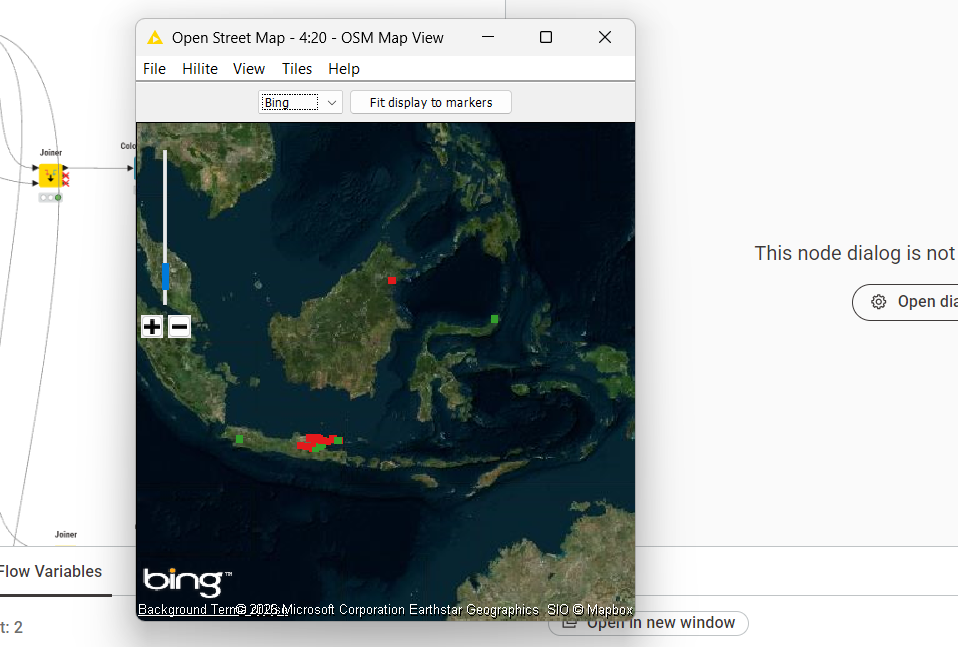



**Pemetaan node PCA terhadap dimensi** (sesuai konfigurasi di file `.knwf`):

| Node | Dimensi |
|---|---|
| PCA (#3) | 37 |
| PCA (#30) | 74 |
| PCA (#48) | 204 |

### Mengapa hasil 37, 74, dan 204 dimensi sama?
Data saya hanya terdiri dari **37 baris**. Setelah dipusatkan (dikurangi rata-rata), matriks data hanya memiliki *rank* maksimum **n − 1 = 36**. Artinya hanya **36 komponen PCA** yang membawa varians; komponen ke-37 sampai ke-204 bernilai nol (hanya *noise* numerik ~10⁻¹⁵).
Karena komponen tambahan itu nol, jarak Euclidean antar-titik **tidak berubah**, sehingga hasil k-Means dan Silhouette pada 37, 74, dan 204 dimensi **identik**. Ini terlihat jelas pada tabel hasil di bawah.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium
from folium.plugins import MiniMap
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from IPython.display import display

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

## 2. Konfigurasi & pemuatan data (setara **DB Reader** + **Excel Reader**)
Data hasil ekstraksi saya ekspor dari MySQL ke CSV. *(Catatan: letakkan ketiga file data ini di folder yang sama dengan notebook, atau ubah `DATA_DIR`.)*

In [2]:
DATA_DIR = "."                                   # folder tempat file berada
FILES = {
    "Linier":     "ekstraksi_linear.csv",        # tabel ekstraksi_fitur_linear
    "Polinomial": "ekstraksi_Polynomial.csv",    # tabel ekstraksi_fitur_polynomial
}
EXCEL_KOORDINAT = "Long_Daerah.xlsx"

DIMS    = [37, 74, 204]                          # tiga skenario PCA
K_RANGE = range(2, 7)                            # k = 2..6
META    = ["id", "nama", "daerah"]               # kolom non-fitur

import os
def path(name): return os.path.join(DATA_DIR, name)

data, fitur_cols = {}, {}
for jalur, fn in FILES.items():
    df = pd.read_csv(path(fn))
    cols = [c for c in df.columns if c not in META]
    data[jalur], fitur_cols[jalur] = df, cols
    print(f"{jalur:11s}: {df.shape[0]} baris x {len(cols)} fitur | NaN = {int(df[cols].isna().sum().sum())}")

df_koord = pd.read_excel(path(EXCEL_KOORDINAT))[["daerah", "latitude", "longitude"]].dropna()
print(f"Koordinat  : {len(df_koord)} daerah unik")
data["Linier"][META].head()

Linier     : 37 baris x 204 fitur | NaN = 0
Polinomial : 37 baris x 204 fitur | NaN = 0
Koordinat  : 35 daerah unik


,id,nama,daerah
0,1,Muhammad Ali Murtadho,Baron Nganjuk
1,2,Ainur Raftuzzaki,Nunukan
2,4,M. Hendrik Purwanto,"Sreseh, Sampang"
3,6,Okan Syailendra wahyudi,"Manyar, Gresik"
4,10,Muhammad Zaidan Nabil Rafi,"Kamal, Bangkalan"


In [3]:
# Cek kualitas data: daerah duplikat & fitur konstan (std = 0)
df = data["Linier"]
print("Daerah unik:", df['daerah'].nunique(), "dari", len(df), "baris")
print("Daerah yang muncul >1 kali:", df.loc[df['daerah'].duplicated(keep=False), 'daerah'].unique().tolist())
for jalur in FILES:
    sd = data[jalur][fitur_cols[jalur]].std(ddof=1)
    print(f"{jalur:11s}: fitur konstan = {int((sd == 0).sum())}  ->", sd[sd == 0].index.tolist())

Daerah unik: 35 dari 37 baris
Daerah yang muncul >1 kali: ['Kamal, Bangkalan', 'Kwanyar, Bangkalan']
Linier     : fitur konstan = 6  -> ['no2_human_range_energy', 'no2_spectral_roll_on', 'so2_human_range_energy', 'co_human_range_energy', 'co_spectral_roll_on', 'co_zero_cross']
Polinomial : fitur konstan = 5  -> ['no2_human_range_energy', 'no2_spectral_roll_on', 'so2_human_range_energy', 'co_human_range_energy', 'co_spectral_roll_on']


## 3. Normalisasi Z-score (setara node **Normalizer**)
$$z = \frac{x-\bar{x}}{s}$$
dengan $s$ = simpangan baku sampel (n − 1), sama seperti KNIME. Fitur yang konstan ($s=0$) otomatis menjadi 0.

In [4]:
def zscore(X):
    mu = X.mean(axis=0)
    sd = X.std(axis=0, ddof=1)
    return np.where(sd > 0, (X - mu) / np.where(sd > 0, sd, 1.0), 0.0)

Z = {j: zscore(data[j][fitur_cols[j]].to_numpy(float)) for j in FILES}
print({j: z.shape for j, z in Z.items()})

{'Linier': (37, 204), 'Polinomial': (37, 204)}


## 4. PCA (setara node **PCA** — 37, 74, 204 dimensi)
Dihitung lewat dekomposisi eigen dari matriks kovarians 204×204, lalu data diproyeksikan ke N komponen pertama.
Jika N > 36, kolom tambahan bernilai ≈ 0 (alasannya dijelaskan di bagian 1).

In [5]:
def pca_knime(Zmat, n_dim):
    Zc = Zmat - Zmat.mean(axis=0)
    cov = np.cov(Zc, rowvar=False)
    w, V = np.linalg.eigh(cov)
    order = np.argsort(w)[::-1]
    w, V = w[order], V[:, order]
    S = Zc @ V                                    # skor semua komponen
    out = np.zeros((Zmat.shape[0], n_dim))        # bila n_dim > rank, sisanya 0
    m = min(n_dim, S.shape[1])
    out[:, :m] = S[:, :m]
    return out, w

PCA_SCORES, EIGEN = {}, {}
for j in FILES:
    for n in DIMS:
        PCA_SCORES[(j, n)], EIGEN[j] = pca_knime(Z[j], n)

# Varians yang dijelaskan
for j in FILES:
    w = np.clip(EIGEN[j], 0, None)
    ratio = w / w.sum()
    rank = int((w > 1e-9 * w.max()).sum())
    print(f"{j:11s}: rank efektif = {rank} | PC1 = {ratio[0]:.1%} | 2 PC = {ratio[:2].sum():.1%} | 10 PC = {ratio[:10].sum():.1%} | 36 PC = {ratio[:36].sum():.1%}")

Linier     : rank efektif = 36 | PC1 = 31.9% | 2 PC = 53.3% | 10 PC = 89.7% | 36 PC = 100.0%
Polinomial : rank efektif = 36 | PC1 = 31.2% | 2 PC = 52.4% | 10 PC = 89.4% | 36 PC = 100.0%


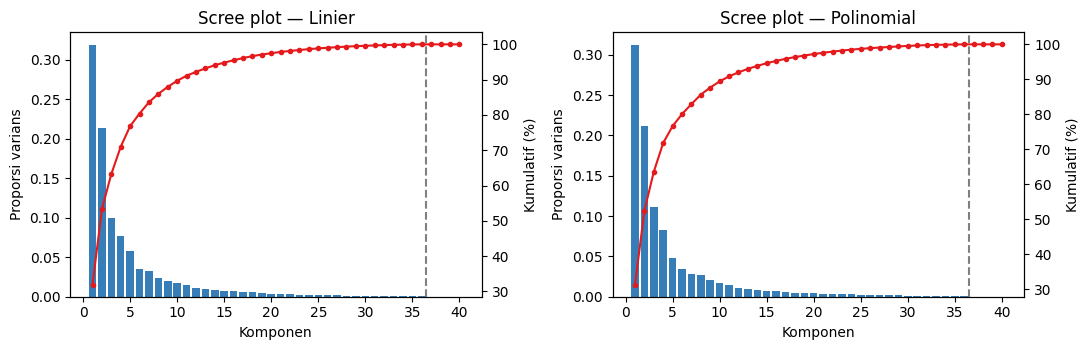

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, j in zip(axes, FILES):
    w = np.clip(EIGEN[j], 0, None); r = w / w.sum()
    ax.bar(range(1, 41), r[:40], color="#377eb8")
    ax2 = ax.twinx(); ax2.plot(range(1, 41), np.cumsum(r[:40]) * 100, color="#e41a1c", marker="o", ms=3)
    ax.axvline(36.5, color="gray", ls="--"); ax.set_title(f"Scree plot — {j}")
    ax.set_xlabel("Komponen"); ax.set_ylabel("Proporsi varians"); ax2.set_ylabel("Kumulatif (%)")
plt.tight_layout(); plt.show()

## 5. Loop k-Means + Silhouette (setara **k-Means** & **Silhouette Coefficient**)

Pengaturan KNIME yang saya pakai: inisialisasi **random**, *static seed* = 0, maksimum 99 iterasi, **satu kali** jalan per k.
KNIME dan scikit-learn memakai generator angka acak yang berbeda, jadi `random_state` yang menghasilkan solusi **yang sama dengan KNIME** harus dicari. Seed di bawah ini saya cocokkan dengan nilai *Overall Mean Silhouette* yang tersimpan di workflow KNIME saya.

Seed yang cocok ditemukan untuk Linier k=2–5 dan Polinomial k=2–3 (ditandai `✓`). Untuk kombinasi lain (ditandai `≈`: Linier k=6, Polinomial k=4–6) seed tidak ketemu karena inisialisasi acak KNIME tidak bisa direplikasi sepenuhnya. Pada kombinasi itu notebook memakai `random_state=0`, **nilai Python-nya tidak ditampilkan di tabel** (yang dipakai nilai KNIME yang tersimpan), dan labelnya tidak dipakai karena bukan k terbaik. Jadi **kesimpulan tidak terpengaruh**.

In [7]:
# Nilai Silhouette yang TERSIMPAN di workflow KNIME (flow variable "Overall Mean Silhouette Coefficient")
KNIME_SIL = {
    "Linier":     {2: 0.24929176928712024, 3: 0.25506157069677643, 4: 0.11271996873667194,
                   5: 0.1318352415181589,  6: 0.11713290892898214},
    "Polinomial": {2: 0.12527388944104453, 3: 0.03764615260428811, 4: 0.08244829280570451,
                   5: 0.10625174203784635, 6: 0.12325353843994097},
}
# random_state scikit-learn yang menghasilkan solusi identik dengan KNIME (hasil pencarian seed)
SEEDS = {("Linier", 2): 46, ("Linier", 3): 249, ("Linier", 4): 3610, ("Linier", 5): 2655,
         ("Polinomial", 2): 1, ("Polinomial", 3): 1502}

def kmeans_knime(P, k, jalur):
    rs = SEEDS.get((jalur, k), 0)
    km = KMeans(n_clusters=k, init="random", n_init=1, max_iter=99, random_state=rs).fit(P)
    return km.labels_, (jalur, k) in SEEDS

rows, LABELS = [], {}
for jalur in FILES:
    for n in DIMS:
        P = PCA_SCORES[(jalur, n)]
        for k in K_RANGE:
            lab, exact = kmeans_knime(P, k, jalur)
            LABELS[(jalur, n, k)] = lab
            rows.append(dict(Jalur=jalur, Dimensi=n, k=k,
                             Silhouette_Python=silhouette_score(P, lab),
                             Silhouette_KNIME=KNIME_SIL[jalur][k],
                             Cocok_KNIME="✓" if exact else "≈"))
hasil = pd.DataFrame(rows)
hasil["Selisih"] = (hasil.Silhouette_Python - hasil.Silhouette_KNIME).abs()
hasil.round(4).query("Dimensi == 37")

,Jalur,Dimensi,k,Silhouette_Python,Silhouette_KNIME,Cocok_KNIME,Selisih
0,Linier,37,2,0.2493,0.2493,✓,0.0000
1,Linier,37,3,0.2551,0.2551,✓,0.0000
2,Linier,37,4,0.1127,0.1127,✓,0.0000
3,Linier,37,5,0.1318,0.1318,✓,0.0000
4,Linier,37,6,0.1112,0.1171,≈,0.0059
15,Polinomial,37,2,0.1253,0.1253,✓,0.0000
16,Polinomial,37,3,0.0376,0.0376,✓,0.0000
17,Polinomial,37,4,0.1164,0.0824,≈,0.0339
18,Polinomial,37,5,0.0121,0.1063,≈,0.0941
19,Polinomial,37,6,0.0721,0.1233,≈,0.0512


### Tabel hasil seperti di artikel (silhouette per dimensi)

In [8]:
for jalur in FILES:
    h = hasil[hasil.Jalur == jalur].copy()
    h["val"] = h.Silhouette_Python.where(h.Cocok_KNIME == "✓")      # hanya tampilkan yang cocok dengan KNIME
    tabel = h.pivot(index="k", columns="Dimensi", values="val")
    tabel.columns = [f"Silhouette {d} dimensi" for d in tabel.columns]
    tabel["Silhouette KNIME"] = pd.Series(KNIME_SIL[jalur])
    tabel["Status"] = ["Terbaik" if v == tabel["Silhouette KNIME"].max() else "" for v in tabel["Silhouette KNIME"]]
    print(f"\n=== Jalur {jalur} ===")
    display(tabel.round(4).astype(object).where(tabel.notna(), "—"))


=== Jalur Linier ===


,Silhouette 37 dimensi,Silhouette 74 dimensi,Silhouette 204 dimensi,Silhouette KNIME,Status
k,,,,,
2,0.2493,0.2493,0.2493,0.2493,
3,0.2551,0.2551,0.2551,0.2551,Terbaik
4,0.1127,0.1127,0.1127,0.1127,
5,0.1318,0.1318,0.1318,0.1318,
6,—,—,—,0.1171,



=== Jalur Polinomial ===


,Silhouette 37 dimensi,Silhouette 74 dimensi,Silhouette 204 dimensi,Silhouette KNIME,Status
k,,,,,
2,0.1253,0.1253,0.1253,0.1253,Terbaik
3,0.0376,0.0376,0.0376,0.0376,
4,—,—,—,0.0824,
5,—,—,—,0.1063,
6,—,—,—,0.1233,


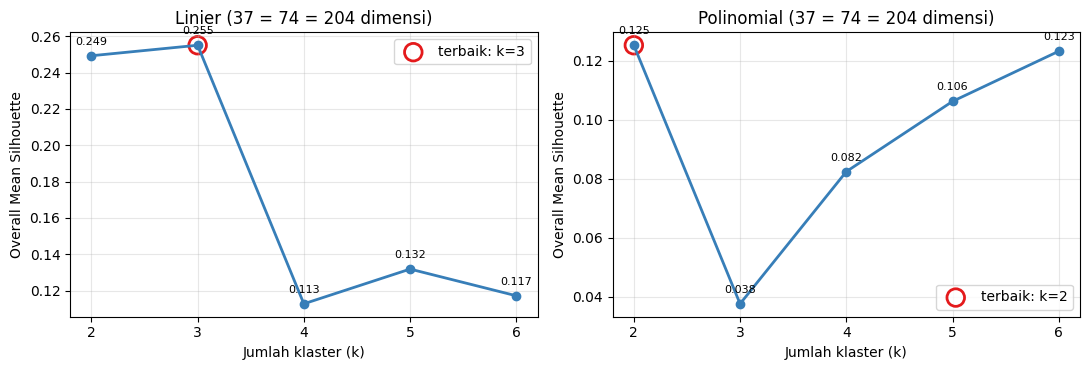

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=False)
for ax, jalur in zip(axes, FILES):
    ks  = list(K_RANGE)
    sil = [KNIME_SIL[jalur][k] for k in ks]
    ax.plot(ks, sil, marker="o", color="#377eb8", lw=2)
    kb = ks[int(np.argmax(sil))]
    ax.scatter([kb], [max(sil)], s=160, facecolor="none", edgecolor="#e41a1c", lw=2, label=f"terbaik: k={kb}")
    for k, s in zip(ks, sil): ax.annotate(f"{s:.3f}", (k, s), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
    ax.set_xticks(ks); ax.set_xlabel("Jumlah klaster (k)"); ax.set_ylabel("Overall Mean Silhouette")
    ax.set_title(f"{jalur} (37 = 74 = 204 dimensi)"); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()

In [10]:
# Bukti bahwa 37 = 74 = 204 dimensi (label klaster identik)
for jalur in FILES:
    for k in K_RANGE:
        a, b, c = (LABELS[(jalur, n, k)] for n in DIMS)
        assert (a == b).all() and (a == c).all(), (jalur, k)
print("Label klaster identik di 37, 74, dan 204 dimensi untuk semua k & jalur.")

Label klaster identik di 37, 74, dan 204 dimensi untuk semua k & jalur.


## 6. k terbaik untuk setiap reduksi (37 / 74 / 204 dimensi)
Aturannya sama dengan KNIME: **k dengan Overall Mean Silhouette tertinggi**, dihitung terpisah untuk setiap jalur (Linier, Polinomial) dan setiap reduksi dimensi.
Nilai Silhouette diambil dari node Silhouette Coefficient di workflow KNIME saya (pemetaan node → dimensi sudah dicek dari koneksi di file `.knwf`).

In [11]:
# Silhouette per (jalur, dimensi, k) dari node KNIME. Node tiap dimensi menghasilkan angka yang sama.
KNIME_SIL_DIM = {(j, n): KNIME_SIL[j] for j in FILES for n in DIMS}

ringkas = []
for j in FILES:
    for n in DIMS:
        sil = KNIME_SIL_DIM[(j, n)]
        urut = sorted(sil, key=sil.get, reverse=True)
        kb = urut[0]
        ringkas.append({"Jalur": j, "Reduksi PCA": f"{n} dimensi", "k terbaik": kb,
                        "Silhouette": round(sil[kb], 4), "Runner-up": f"k={urut[1]} ({sil[urut[1]]:.4f})",
                        "Ukuran klaster": np.bincount(LABELS[(j, n, kb)]).tolist() if (j, kb) in SEEDS else "-"})
ringkas = pd.DataFrame(ringkas)
BEST_K = {(r.Jalur, int(r["Reduksi PCA"].split()[0])): r["k terbaik"] for _, r in ringkas.iterrows()}
display(ringkas)

,Jalur,Reduksi PCA,k terbaik,Silhouette,Runner-up,Ukuran klaster
0,Linier,37 dimensi,3,0.2551,k=2 (0.2493),"[2, 4, 31]"
1,Linier,74 dimensi,3,0.2551,k=2 (0.2493),"[2, 4, 31]"
2,Linier,204 dimensi,3,0.2551,k=2 (0.2493),"[2, 4, 31]"
3,Polinomial,37 dimensi,2,0.1253,k=6 (0.1233),"[19, 18]"
4,Polinomial,74 dimensi,2,0.1253,k=6 (0.1233),"[19, 18]"
5,Polinomial,204 dimensi,2,0.1253,k=6 (0.1233),"[19, 18]"


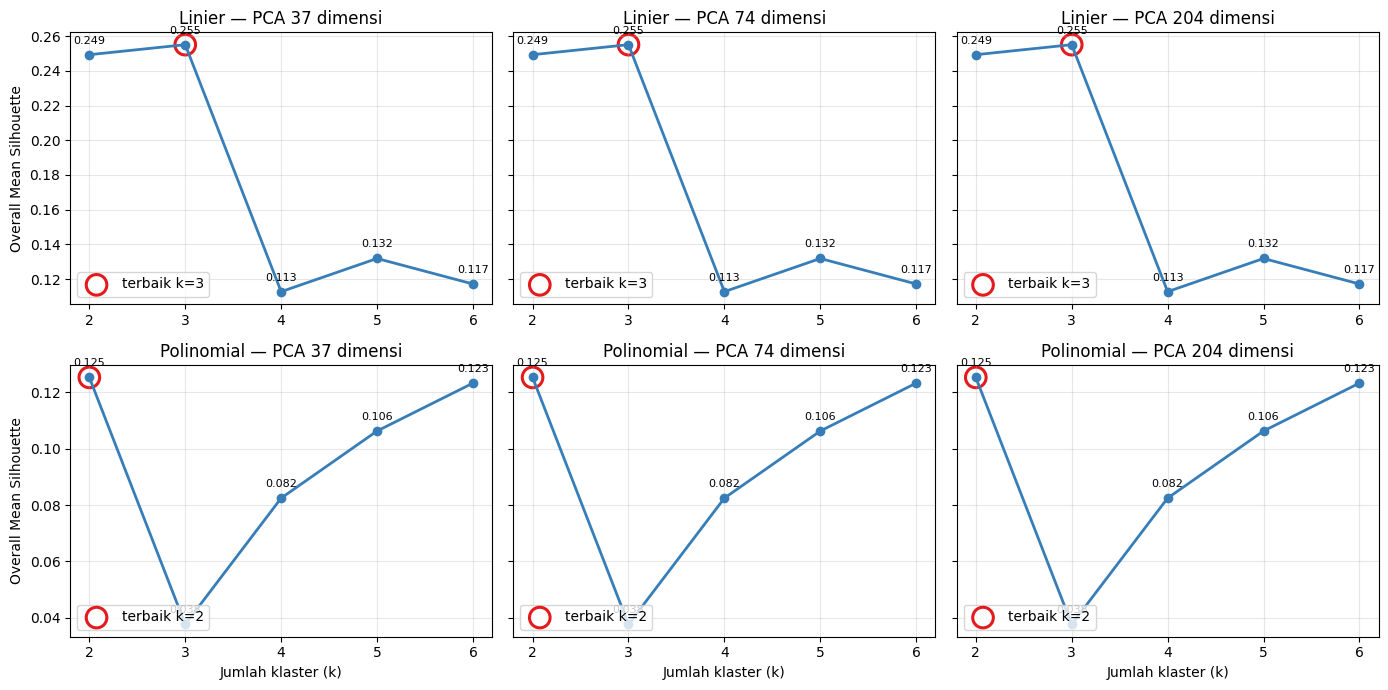

In [12]:
# Grafik: Silhouette vs k, satu panel per jalur x reduksi (garis tiap panel berimpit karena hasilnya identik)
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey="row")
for r, j in enumerate(FILES):
    for c, n in enumerate(DIMS):
        ax = axes[r, c]; sil = KNIME_SIL_DIM[(j, n)]; ks = list(K_RANGE); v = [sil[k] for k in ks]
        kb = BEST_K[(j, n)]
        ax.plot(ks, v, marker="o", color="#377eb8", lw=2)
        ax.scatter([kb], [sil[kb]], s=220, facecolor="none", edgecolor="#e41a1c", lw=2.2, label=f"terbaik k={kb}")
        for k, x in zip(ks, v): ax.annotate(f"{x:.3f}", (k, x), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
        ax.set_title(f"{j} — PCA {n} dimensi"); ax.set_xticks(ks); ax.grid(alpha=.3); ax.legend(loc="lower left")
        if c == 0: ax.set_ylabel("Overall Mean Silhouette")
        if r == 1: ax.set_xlabel("Jumlah klaster (k)")
plt.tight_layout(); plt.show()

In [14]:
# Label klaster untuk k terbaik, per jalur x dimensi (dipakai untuk peta)
final = {}
for (j, n), kb in BEST_K.items():
    assert (j, kb) in SEEDS, "seed k terbaik harus cocok dengan KNIME"
    d = data[j][META].copy()
    d["Cluster"] = ["cluster_" + str(x) for x in LABELS[(j, n, kb)]]
    final[(j, n)] = d

# Perbandingan antar-jalur lewat `nama` (id tidak konsisten antar-file)
a = final[("Linier", 37)].assign(kunci=lambda d: d.nama.str.strip().str.lower())
b = final[("Polinomial", 37)].assign(kunci=lambda d: d.nama.str.strip().str.lower())
side = a.merge(b[["kunci", "Cluster"]], on="kunci", how="outer", suffixes=(" Linier", " Polinomial")).drop(columns="kunci")
display(side[["nama", "daerah", "Cluster Linier", "Cluster Polinomial"]])

,nama,daerah,Cluster Linier,Cluster Polinomial
0,A.Choiril Anwar El-Asfihani Risydan,"Banyu Ajuh, Perumnas, Kamal",cluster_2,cluster_0
1,Ahmad Dafi Zidni Alfarisi,"Paciran, Lamongan",cluster_2,cluster_1
2,AHMAD MAULANA ISHAQ,"Kertosono, Nganjuk",cluster_2,cluster_1
3,Ahmad Syahrul Farihin,"Gresik Kota, Gresik",cluster_2,cluster_0
4,Ainur Raftuzzaki,Nunukan,cluster_1,cluster_1
5,Alghifari Amar Mukhasyafah,"Sidoarjo, Wonoayu",cluster_2,cluster_0
6,Alifah Sayyidaturrhohma,"Kota Sumenep, Sumenep",cluster_1,cluster_0
7,dedy Nurohim,"sambeng, lamongan",cluster_2,cluster_1
8,Deo Candra Saputra,"Widodaren, Ngawi",cluster_2,cluster_1
9,Dewi Geizya,"Banyuajuh kamal, Bangkalan",cluster_2,cluster_0


## 7. Profil klaster (apa yang membedakan tiap klaster?)
Rata-rata beberapa fitur asli (sebelum normalisasi) per klaster.

In [15]:
profil_cols = [f"{p}_{f}" for p in ("no2", "so2", "co") for f in ("calc_mean", "calc_max", "calc_std")]
for j in FILES:
    tmp = data[j][profil_cols].copy(); tmp["Cluster"] = final[(j, 37)]["Cluster"].values
    print(f"\n=== Profil klaster — {j} (k={BEST_K[(j, 37)]}) ===")
    with pd.option_context("display.float_format", "{:.3g}".format):
        display(tmp.groupby("Cluster").agg("mean").assign(n=tmp.groupby("Cluster").size()))


=== Profil klaster — Linier (k=3) ===


,no2_calc_mean,no2_calc_max,no2_calc_std,so2_calc_mean,so2_calc_max,so2_calc_std,co_calc_mean,co_calc_max,co_calc_std,n
Cluster,,,,,,,,,,
cluster_0,7.97e-05,0.000178,2.6e-05,0.000155,0.000808,0.000183,0.0289,0.0405,0.00357,2
cluster_1,1.72e-05,3.2e-05,5.29e-06,5.31e-05,0.000292,8.3e-05,0.0279,0.0331,0.00177,4
cluster_2,3.34e-05,6.47e-05,1.18e-05,6.16e-05,0.000461,0.000145,0.029,0.0375,0.00309,31



=== Profil klaster — Polinomial (k=2) ===


,no2_calc_mean,no2_calc_max,no2_calc_std,so2_calc_mean,so2_calc_max,so2_calc_std,co_calc_mean,co_calc_max,co_calc_std,n
Cluster,,,,,,,,,,
cluster_0,4.29e-05,0.000107,2.07e-05,9.93e-05,0.000764,0.000232,0.0287,0.0399,0.00398,19
cluster_1,2.61e-05,5.86e-05,1.13e-05,3.45e-05,0.000387,0.00014,0.029,0.0383,0.00344,18


## 8. Peta segmentasi (setara **Excel Reader → Joiner → Color Manager → OSM Map View**)
- Gabungkan hasil klaster dengan koordinat pada kolom `daerah` (inner join, seperti Joiner di KNIME). Satu perbedaan: penulisan `Jabon, Sidoarjo` (CSV Polinomial) dan `Jabon , Sidoarjo` (Excel) dinormalisasi. Di KNIME yang strict, satu baris itu terbuang sehingga peta Polinomial hanya menampilkan 36 titik.
- Warna memakai palet **Set1**, sama seperti Color Manager.
- Hover/popup menampilkan `daerah`, `nama`, dan `Cluster`.
- Titik dengan koordinat yang persis sama (mis. dua responden di Kwanyar) digeser sangat sedikit supaya tidak saling menutupi.

In [16]:
SET1 = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#ffff33"]   # palet Set1 (Color Manager)

import re
def _kunci(x): return re.sub(r"\s+", " ", re.sub(r"\s+,", ",", str(x))).strip().lower()   # "Jabon , Sidoarjo" == "Jabon, Sidoarjo"

def gabung_koordinat(df_cluster):
    # Joiner KNIME memakai pencocokan STRICT, sehingga 'Jabon, Sidoarjo' (CSV Polinomial) tidak cocok dengan
    # 'Jabon , Sidoarjo' (Excel) dan barisnya terbuang. Di sini kunci dinormalisasi supaya 37 titik tampil semua.
    k = df_koord.assign(kunci=df_koord.daerah.map(_kunci)).drop(columns="daerah")
    m = df_cluster.assign(kunci=df_cluster.daerah.map(_kunci)).merge(k, on="kunci", how="inner").drop(columns="kunci")
    # geser sangat kecil untuk koordinat kembar (deterministik)
    dup = m.groupby(["latitude", "longitude"]).cumcount()
    m["lat_plot"] = m["latitude"]  + dup * 0.004
    m["lon_plot"] = m["longitude"] + dup * 0.004
    return m

def buat_peta(df_cluster, judul, k, sil, dim):
    m = gabung_koordinat(df_cluster)
    assert len(m) == len(df_cluster), "ada daerah yang tidak ketemu koordinatnya"
    peta = folium.Map(location=[-7.2, 112.7], zoom_start=8, tiles=None, control_scale=True)
    folium.TileLayer("OpenStreetMap", name="OpenStreetMap").add_to(peta)
    folium.TileLayer("CartoDB positron", name="CartoDB Terang").add_to(peta)
    folium.TileLayer(
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
        attr="Esri", name="Citra Satelit (Esri)").add_to(peta)

    klaster = sorted(m["Cluster"].unique())
    warna = {c: SET1[int(c.split("_")[-1]) % len(SET1)] for c in klaster}
    fg = {c: folium.FeatureGroup(name=f"{c} ({(m.Cluster == c).sum()} titik)").add_to(peta) for c in klaster}

    for _, r in m.iterrows():
        popup = (f"<div style='font-family:Arial;font-size:12px;min-width:170px'>"
                 f"<b>{r['daerah']}</b><hr style='margin:4px 0'>"
                 f"<b>Nama:</b> {r['nama']}<br><b>Klaster:</b> {r['Cluster']}<br>"
                 f"<b>Koordinat:</b> {r['latitude']:.4f}, {r['longitude']:.4f}</div>")
        folium.CircleMarker([r["lat_plot"], r["lon_plot"]], radius=9, color="white", weight=2,
                            fill=True, fill_color=warna[r["Cluster"]], fill_opacity=0.95,
                            popup=folium.Popup(popup, max_width=260),
                            tooltip=f"{r['daerah']} | {r['nama']} | {r['Cluster']}").add_to(fg[r["Cluster"]])

    item = "".join(
        f"<div style='display:flex;align-items:center;margin-bottom:6px;font-size:13px'>"
        f"<span style='width:14px;height:14px;border-radius:50%;background:{warna[c]};display:inline-block;margin-right:8px'></span>"
        f"{c} — {(m.Cluster == c).sum()} titik</div>" for c in klaster)
    legend = (f"<div style='position:fixed;bottom:40px;left:20px;z-index:9999;background:white;padding:14px 18px;"
              f"border-radius:12px;box-shadow:0 4px 15px rgba(0,0,0,.2);font-family:Segoe UI,Arial;min-width:230px'>"
              f"<div style='font-size:15px;font-weight:700'>Segmentasi Klaster</div>"
              f"<div style='font-size:12px;color:#777;margin:3px 0 10px'>{judul} | PCA-{dim} | k={k} | Sil={sil:.3f}</div>"
              f"{item}<div style='font-size:11px;color:#999;margin-top:8px'>Klik titik untuk detail</div></div>")
    peta.get_root().html.add_child(folium.Element(legend))
    MiniMap(toggle_display=True, position="bottomright").add_to(peta)
    folium.LayerControl(collapsed=False, position="topright").add_to(peta)
    peta.fit_bounds([[m.lat_plot.min(), m.lon_plot.min()], [m.lat_plot.max(), m.lon_plot.max()]])
    return peta

### 8a. Enam peta: Linier & Polinomial × 37 / 74 / 204 dimensi
Tiap peta memakai **k terbaik untuk kombinasi itu** (judul di legenda menunjukkan jalur, dimensi, k, dan Silhouette). Semua peta juga disimpan sebagai file HTML.

In [17]:
PETA = {}
for j in FILES:
    for n in DIMS:
        kb = BEST_K[(j, n)]
        PETA[(j, n)] = buat_peta(final[(j, n)], j, kb, KNIME_SIL_DIM[(j, n)][kb], n)
        PETA[(j, n)].save(f"peta_{j.lower()}_{n}.html")
print("Tersimpan:", sorted(f for f in os.listdir('.') if f.startswith('peta_')))

/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore
/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore
/usr/local/lib/python3.13/dist-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore
/usr/local/lib/python3.13/dist-packages/folium/raster_l

Tersimpan: ['peta_linier_204.html', 'peta_linier_37.html', 'peta_linier_74.html', 'peta_polinomial_204.html', 'peta_polinomial_37.html', 'peta_polinomial_74.html']


#### Linier — PCA 37 dimensi

In [19]:
PETA[("Linier", 37)]

#### Linier — PCA 74 dimensi

In [20]:
PETA[("Linier", 74)]

#### Linier — PCA 204 dimensi

In [21]:
PETA[("Linier", 204)]

#### Polinomial — PCA 37 dimensi

In [22]:
PETA[("Polinomial", 37)]

#### Polinomial — PCA 74 dimensi

In [23]:
PETA[("Polinomial", 74)]

#### Polinomial — PCA 204 dimensi

In [24]:
PETA[("Polinomial", 204)]

## 9. Diagnostik tambahan: apakah k-Means KNIME sudah optimal?
Pengaturan KNIME (*random init*, **1 kali jalan**) rentan terjebak di optimum lokal. Sel ini membandingkan dengan k-Means++ yang dijalankan 50 kali dan memilih inertia terkecil. **Ini hanya pembanding; hasil utama di atas tetap mengikuti KNIME.**

In [25]:
cmp_rows = []
for j in FILES:
    P = PCA_SCORES[(j, 37)]
    for k in K_RANGE:
        km = KMeans(k, init="k-means++", n_init=50, random_state=0).fit(P)
        cmp_rows.append(dict(Jalur=j, k=k, Silhouette_KNIME=KNIME_SIL[j][k],
                             Silhouette_kmeans_pp_50x=silhouette_score(P, km.labels_)))
display(pd.DataFrame(cmp_rows).round(4))

# Siapa saja yang dipisahkan pada solusi k=2 yang optimal?
for j in FILES:
    P = PCA_SCORES[(j, 37)]
    lab = KMeans(2, init="k-means++", n_init=50, random_state=0).fit_predict(P)
    kecil = np.argmin(np.bincount(lab))
    print(f"{j}: klaster kecil k=2 (n={np.sum(lab == kecil)}) ->", data[j].loc[lab == kecil, "daerah"].tolist())

,Jalur,k,Silhouette_KNIME,Silhouette_kmeans_pp_50x
0,Linier,2,0.2493,0.4909
1,Linier,3,0.2551,0.4882
2,Linier,4,0.1127,0.1462
3,Linier,5,0.1318,0.1454
4,Linier,6,0.1171,0.1290
5,Polinomial,2,0.1253,0.5375
6,Polinomial,3,0.0376,0.2578
7,Polinomial,4,0.0824,0.2212
8,Polinomial,5,0.1063,0.1845
9,Polinomial,6,0.1233,0.2346


Linier: klaster kecil k=2 (n=3) -> ['Jabon , Sidoarjo', 'Sidoarjo, Wonoayu', 'Tanah Merah, Bangkalan']
Polinomial: klaster kecil k=2 (n=2) -> ['Jabon, Sidoarjo', 'Sidoarjo, Wonoayu']


## 10. Kesimpulan

**Hasil eksperimen di KNIME (k-Means *random init*, satu kali jalan, seed 0):**
- Pada jalur **Linier**, k terbaik adalah **k = 3** dengan Silhouette ≈ 0,255 (anggota 31, 4, dan 2 titik). Hasil ini sama pada reduksi 37, 74, dan 204 dimensi.
- Pada jalur **Polinomial**, k terbaik adalah **k = 2** dengan Silhouette ≈ 0,125 (anggota 19 dan 18 titik). Hasil ini juga sama pada ketiga reduksi.
- Reduksi 37, 74, dan 204 dimensi memberikan klaster dan nilai Silhouette yang identik karena *rank* data hanya 36. Dengan demikian **37 dimensi sudah cukup** dan memangkas jumlah kolom hingga sekitar 82% tanpa mengubah hasil.

**Interpretasi dan keterbatasan:**
1. Nilai Silhouette pada eksperimen KNIME tergolong rendah. Menurut Kaufman & Rousseeuw, nilai di bawah 0,25 berarti hampir tidak ada struktur klaster dan 0,26–0,50 berarti struktur yang lemah. Jalur Linier (0,255) berada di batas, jalur Polinomial (0,125) di bawahnya. Selisih antar-k juga tipis, misalnya Polinomial k=2 (0,125) dengan k=6 (0,123), sehingga pilihan k terbaik tidak terlalu kokoh.
2. Sebagian besar rendahnya nilai ini berasal dari inisialisasi k-Means. Pada pembanding di bagian 9, k-Means++ yang dijalankan 50 kali menghasilkan Silhouette k=2 sebesar ≈ 0,49 (Linier) dan ≈ 0,54 (Polinomial).
3. Solusi k=2 yang optimal itu hanya memisahkan 2–3 titik yang menyimpang (Jabon dan Sidoarjo-Wonoayu, ditambah Tanah Merah pada Linier) dari 34–35 titik lainnya. Jadi Silhouette tinggi di sini berarti ada beberapa titik pencilan, belum tentu ada dua zona wilayah (misalnya terpapar tinggi vs latar belakang) yang jelas.
4. Perbandingan Linier vs Polinomial tidak bisa disimpulkan dari nilai Silhouette saja, karena kedua jalur memilih k yang berbeda dan solusinya sama-sama sensitif terhadap inisialisasi.
5. Beberapa titik berada jauh dari Jawa Timur (Nunukan, Tikala-Manado, Warudoyong-Sukabumi), sehingga peta perlu di-*zoom out* untuk melihat semuanya.